Import

In [1]:
import pandas as pd
import numpy as np
import torch
import re

from datasets import load_dataset, Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
df = pd.read_csv("hf://datasets/sai1908/Mental_Health_Condition_Classification/Mental Health Text Dataset for Emotion and Condition Classification.csv")

In [ ]:
df

,text,status
0,"""My mind is a never-ending cycle of worry, and...",anxiety
1,Despite the sun shining and birds singing outs...,bipolar
2,"I'm drowning in responsibilities, each one dem...",stress
3,"""My emotions shift like the wind, leaving me u...",personality disorder
4,"I'm trapped in a whirlwind of thoughts, unable...",anxiety
...,...,...
103483,"I long to embrace my true self, yet the mirror...",personality disorder
103484,"""My mind is a whirlwind of worst-case scenario...",anxiety
103485,Bipolar disorder: From elated excitement to cr...,bipolar
103486,"""Despite my best efforts, the constant stream ...",stress


Data Cleaning

In [ ]:
def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r'http\S+|www\.\S+', ' ', s)
    s = re.sub(r'@\w+|#\w+', ' ', s)
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [ ]:
df['text'] = df['text'].astype(str).apply(clean_text)

In [ ]:
df

,text,status
0,my mind is a never ending cycle of worry and e...,anxiety
1,despite the sun shining and birds singing outs...,bipolar
2,i m drowning in responsibilities each one dema...,stress
3,my emotions shift like the wind leaving me unc...,personality disorder
4,i m trapped in a whirlwind of thoughts unable ...,anxiety
...,...,...
103483,i long to embrace my true self yet the mirrors...,personality disorder
103484,my mind is a whirlwind of worst case scenarios...,anxiety
103485,bipolar disorder from elated excitement to cru...,bipolar
103486,despite my best efforts the constant stream of...,stress


Label Encoding and Mapping

In [ ]:
label2id = {label: i for i, label in enumerate(df["status"].unique())}
id2label = {i: label for label, i in label2id.items()}

df["label"] = df["status"].map(label2id)

In [ ]:
df[["status", "label"]].head()

,status,label
0,anxiety,0
1,bipolar,1
2,stress,2
3,personality disorder,3
4,anxiety,0


Train-Test-Split

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

In [ ]:
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])

Tokenization

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=128
    )

In [ ]:
train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
val_ds   = val_ds.map(tokenize, batched=True, remove_columns=["text"])

Map:   0%|          | 0/93139 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer)

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

Fine Tuning the BERT model

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert-results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-2949989740.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.257700,0.332336,0.905305,0.900120,0.905064
2,0.165600,0.381369,0.907721,0.902931,0.907537


Epoch,Training Loss,Validation Loss


TrainOutput(global_step=23286, training_loss=0.2066643127284795, metrics={'train_runtime': 4496.6893, 'train_samples_per_second': 41.426, 'train_steps_per_second': 5.178, 'total_flos': 1.17274766395896e+16, 'train_loss': 0.2066643127284795, 'epoch': 2.0})

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    top_k_accuracy_score,
    auc
)
from wordcloud import WordCloud
from sklearn.preprocessing import label_binarize
from sklearn.metrics import cohen_kappa_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import matthews_corrcoef

In [ ]:
preds = trainer.predict(val_ds)

y_true = preds.label_ids
y_logits = preds.predictions
y_pred = y_logits.argmax(axis=1)
y_prob = torch.softmax(torch.tensor(y_logits), dim=1).numpy()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=id2label.values()
    )
)

                      precision    recall  f1-score   support

             anxiety       0.96      0.97      0.97      1689
             bipolar       0.97      0.97      0.97      1379
              stress       0.96      0.94      0.95      1500
personality disorder       0.98      0.98      0.98      1407
              normal       0.95      0.95      0.95      1618
          depression       0.78      0.77      0.77      1598
            suicidal       0.73      0.73      0.73      1158

            accuracy                           0.91     10349
           macro avg       0.90      0.90      0.90     10349
        weighted avg       0.91      0.91      0.91     10349



In [ ]:
print("Micro Precision:", precision_score(y_true, y_pred, average="micro"))
print("Macro Precision:", precision_score(y_true, y_pred, average="macro"))
print("Weighted Precision:", precision_score(y_true, y_pred, average="weighted"))

print("Micro Recall:", recall_score(y_true, y_pred, average="micro"))
print("Macro Recall:", recall_score(y_true, y_pred, average="macro"))
print("Weighted Recall:", recall_score(y_true, y_pred, average="weighted"))

print("Micro F1:", f1_score(y_true, y_pred, average="micro"))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))

Micro Precision: 0.9077205527104067
Macro Precision: 0.9029182782977144
Weighted Precision: 0.9074095180704457
Micro Recall: 0.9077205527104067
Macro Recall: 0.902996823291476
Weighted Recall: 0.9077205527104067
Micro F1: 0.9077205527104067
Macro F1: 0.9029307189791578
Weighted F1: 0.9075368033377432


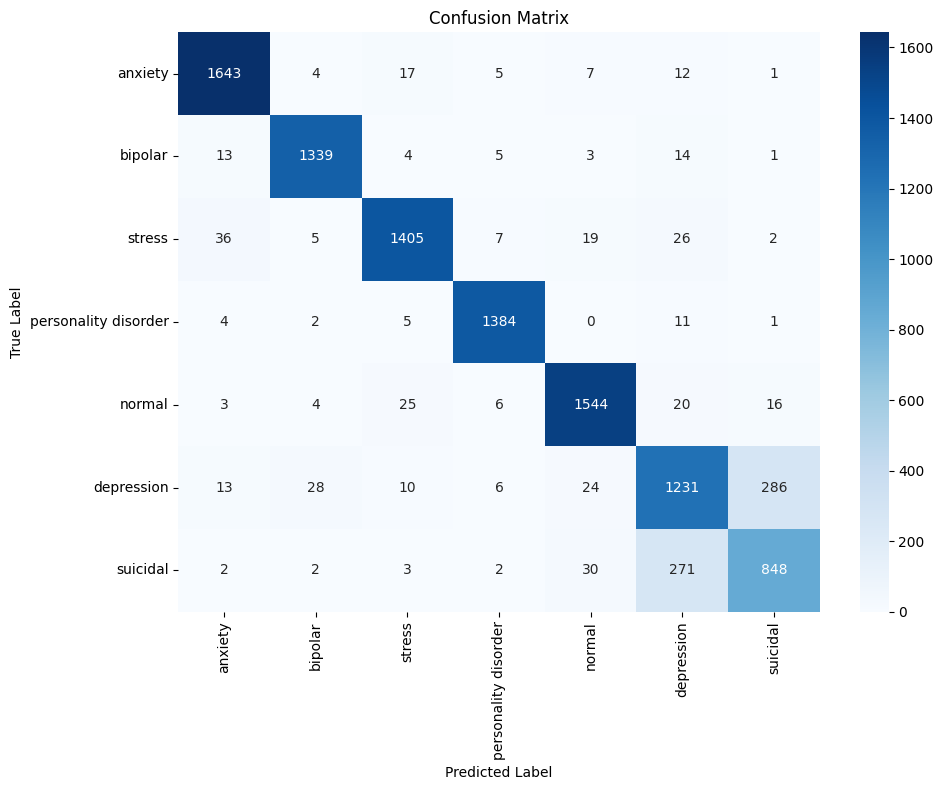

In [ ]:
labels = [id2label[i] for i in sorted(id2label.keys())]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Precision Recall Curve

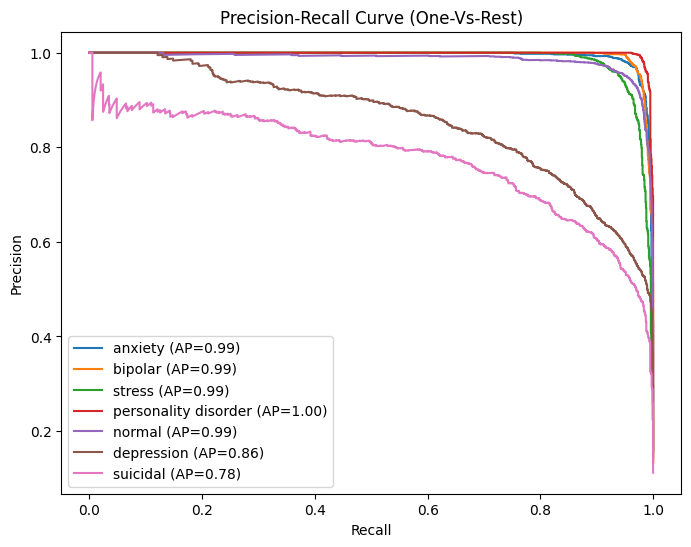

In [ ]:
labels = sorted(id2label.keys())
class_names = [id2label[i] for i in labels]

y_true_bin = label_binarize(y_true, classes=labels)

plt.figure(figsize=(8, 6))

for i, name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i], y_prob[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (One-Vs-Rest)")
plt.legend()
plt.show()

ROC Curve ONE VS REST

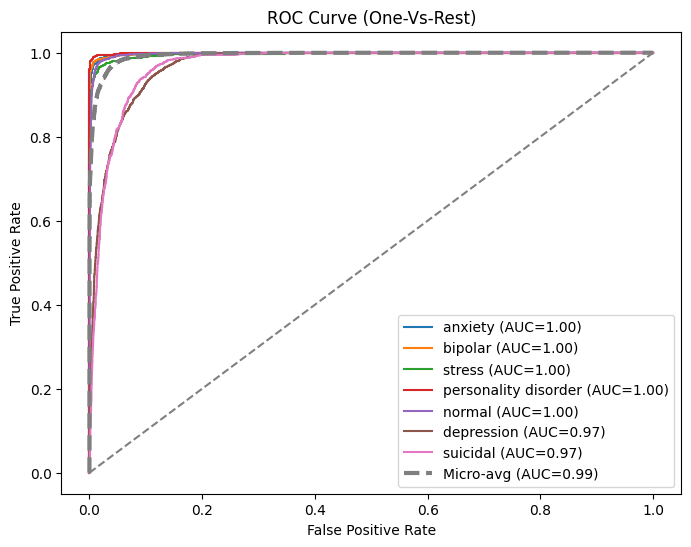

In [ ]:
plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(
    fpr_micro, tpr_micro,
    linestyle="--", linewidth=3,
    label=f"Micro-avg (AUC={roc_auc_micro:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-Vs-Rest)")
plt.legend()
plt.show()

In [ ]:
train_preds = trainer.predict(train_ds)

y_true_train = train_preds.label_ids
y_logits_train = train_preds.predictions
y_prob_train = torch.softmax(
    torch.tensor(y_logits_train), dim=1
).numpy()

auc_train = roc_auc_score(
    y_true_train,
    y_prob_train,
    average="macro",
    multi_class="ovr"
)

print(f"Train Macro AUC: {auc_train:.4f}")
print(f"Val   Macro AUC: {auc_macro:.4f}")
print(f"Difference:     {auc_train - auc_macro:.4f}")

Train Macro AUC: 0.9987
Val   Macro AUC: 0.9906
Difference:     0.0081


Matthews Correlation Coefficient (MCC)

In [ ]:
mcc = matthews_corrcoef(y_true, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.8921


Cohen’s Kappa

In [ ]:
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen’s Kappa: {kappa:.4f}")

Cohen’s Kappa: 0.8921


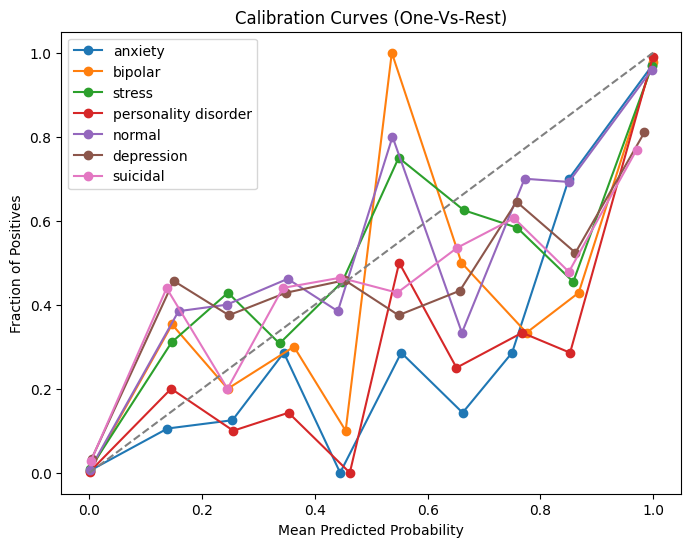

In [ ]:
plt.figure(figsize=(8, 6))

for i, name in enumerate(class_names):
    prob_true, prob_pred = calibration_curve(
        y_true_bin[:, i],
        y_prob[:, i],
        n_bins=10
    )
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves (One-Vs-Rest)")
plt.legend()
plt.show()

Model Performance

In [ ]:
example_texts = [
    "My heart keeps racing and I constantly worry about things that haven’t even happened yet.",
    "I had a productive day today and I feel calm and satisfied with my routine.",
    "I feel empty every day, nothing excites me anymore and getting out of bed feels pointless.",
    "I am overwhelmed with deadlines and responsibilities and I feel mentally exhausted all the time.",
    "I struggle to maintain relationships and my sense of identity changes depending on who I am with.",
    "Some days I feel unstoppable and full of energy, and other days I feel extremely low and hopeless.",
    "I feel like a burden to everyone and sometimes I think everyone would be better off without me."
]

In [ ]:
device = next(model.parameters()).device

inputs = tokenizer(
    example_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

In [ ]:
inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

In [ ]:
probs = torch.softmax(logits, dim=1)
pred_ids = torch.argmax(probs, dim=1)

In [ ]:
for text, pid, prob in zip(example_texts, pred_ids, probs):
    label = id2label[pid.item()]
    confidence = prob[pid].item()

    print("Text:", text)
    print(f"Predicted label: {label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 60)

Text: My heart keeps racing and I constantly worry about things that haven’t even happened yet.
Predicted label: anxiety
Confidence: 0.9999
------------------------------------------------------------
Text: I had a productive day today and I feel calm and satisfied with my routine.
Predicted label: bipolar
Confidence: 0.8268
------------------------------------------------------------
Text: I feel empty every day, nothing excites me anymore and getting out of bed feels pointless.
Predicted label: depression
Confidence: 0.9771
------------------------------------------------------------
Text: I am overwhelmed with deadlines and responsibilities and I feel mentally exhausted all the time.
Predicted label: stress
Confidence: 0.9999
------------------------------------------------------------
Text: I struggle to maintain relationships and my sense of identity changes depending on who I am with.
Predicted label: personality disorder
Confidence: 1.0000
---------------------------------------

Save the Model

In [ ]:
save_path = "./saved_bert_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

('./saved_bert_model/tokenizer_config.json',
 './saved_bert_model/special_tokens_map.json',
 './saved_bert_model/vocab.txt',
 './saved_bert_model/added_tokens.json')

In [ ]:
!zip -r bert_model.zip /content/saved_bert_model

  adding: content/saved_bert_model/ (stored 0%)
  adding: content/saved_bert_model/vocab.txt (deflated 53%)
  adding: content/saved_bert_model/special_tokens_map.json (deflated 42%)
  adding: content/saved_bert_model/model.safetensors (deflated 7%)
  adding: content/saved_bert_model/config.json (deflated 53%)
  adding: content/saved_bert_model/training_args.bin (deflated 53%)
  adding: content/saved_bert_model/tokenizer_config.json (deflated 75%)


In [ ]:
from google.colab import files
files.download("bert_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>